## Tokenization Practice and Simple Document Similarity

For this notebook, you have been provided the top 50 most downloaded books from Project Gutenberg over the last 90 days as text files.

In [18]:
import re
import glob
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np

from nltk import sent_tokenize, word_tokenize, regexp_tokenize
from nltk.corpus import stopwords

from collections import Counter

Given a filepath, you can open the file and use the `read` method to extract the contents as a string.

For example, if we want to import the full text of War and Peace, we can do that using the following block of code.

In [19]:
filepath = 'books/War and Peace by graf Leo Tolstoy.txt'

with open(filepath, encoding = 'utf-8') as fi:
    book = fi.read()

You'll notice that there is some metadata at the top of the file and at the bottom of the file.

In [21]:
book[:1000]

'\ufeffThe Project Gutenberg eBook of War and Peace, by Leo Tolstoy\n\nThis eBook is for the use of anyone anywhere in the United States and\nmost other parts of the world at no cost and with almost no restrictions\nwhatsoever. You may copy it, give it away or re-use it under the terms\nof the Project Gutenberg License included with this eBook or online at\nwww.gutenberg.org. If you are not located in the United States, you\nwill have to check the laws of the country where you are located before\nusing this eBook.\n\nTitle: War and Peace\n\nAuthor: Leo Tolstoy\n\nTranslators: Louise and Aylmer Maude\n\nRelease Date: April, 2001 [eBook #2600]\n[Most recently updated: January 21, 2019]\n\nLanguage: English\n\nCharacter set encoding: UTF-8\n\nProduced by: An Anonymous Volunteer and David Widger\n\n*** START OF THE PROJECT GUTENBERG EBOOK WAR AND PEACE ***\n\n\n\n\nWAR AND PEACE\n\n\nBy Leo Tolstoy/Tolstoi\n\n\n    Contents\n\n    BOOK ONE: 1805\n\n    CHAPTER I\n\n    CHAPTER II\n\n    CH

In [22]:
book[-18420:-18000]

'scious.\n\n\n\n\n*** END OF THE PROJECT GUTENBERG EBOOK WAR AND PEACE ***\n\nUpdated editions will replace the previous one--the old editions will\nbe renamed.\n\nCreating the works from print editions not protected by U.S. copyright\nlaw means that no one owns a United States copyright in these works,\nso the Foundation (and you!) can copy and distribute it in the\nUnited States without permission and without paying copyright\nro'

Write some code that will remove this text at the bottom and top of the string.

**Hint:** You might want to make use of the [`re.search`](https://docs.python.org/3/library/re.html#re.search) function from the `re` library.

In [23]:
book = book[:re.search(r"\*\*\* END", book).span()[0]]

In [24]:
book = book[re.search(r"\*\*\* .+", book).span()[1]]

In [25]:
book[:100]

'\n'

If we want to be able to scale up our analysis to multiple books, it would be nice to have a function to use repeatedly. Write a function called `import_book` which takes as an argument a filepath and returns the contents of that file as a string with the metadata at the top and bottom removed.

In [26]:
def import_book(filepath):
    # Open and read the file
    with open(filepath, encoding='utf-8') as fi:
        book = fi.read()

    book = book[:re.search(r"\*\*\* END", book).span()[0]]
    book = book[re.search(r"\*\*\* .+", book).span()[1]:]

    return book

In [27]:
filepath = 'books/A Christmas Carol in Prose; Being a Ghost Story of Christmas by Charles Dickens.txt'

book = import_book(filepath)

Now, let's utilize our function to import all of the books into a data structure of some kind.

First, we need to be able to iterate through the list of filepaths. For this, we can use the `glob` function. This function takes as agument a pattern to match. Try it out.

In [20]:
glob.glob('books/*.txt')

['books/Pygmalion by Bernard Shaw.txt',
 'books/The War of the Worlds by H. G.  Wells.txt',
 'books/Leviathan by Thomas Hobbes.txt',
 'books/Don Quixote by Miguel de Cervantes Saavedra.txt',
 'books/The Awakening, and Selected Short Stories by Kate Chopin.txt',
 'books/The Count of Monte Cristo, Illustrated by Alexandre Dumas.txt',
 'books/Les Misérables by Victor Hugo.txt',
 'books/The Republic by Plato.txt',
 'books/Walden, and On The Duty Of Civil Disobedience by Henry David Thoreau.txt',
 'books/Dubliners by James Joyce.txt',
 'books/Great Expectations by Charles Dickens.txt',
 'books/Anthem by Ayn Rand.txt',
 'books/Anna Karenina by graf Leo Tolstoy.txt',
 'books/The Yellow Wallpaper by Charlotte Perkins Gilman.txt',
 'books/Moby Dick; Or, The Whale by Herman Melville.txt',
 'books/The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt',
 'books/The Scarlet Letter by Nathaniel Hawthorne.txt',
 'books/The Prince by Niccolò Machiavelli.txt',
 'books/Japanese Girls and Women b

In [28]:
filepath = glob.glob('books/*.txt')[0]
filepath

'books/Pygmalion by Bernard Shaw.txt'

It would be nice to save the title of each book without the extra pieces around it. Write code that will remove the "books/" from the front of the filepath and the ".txt" from the end. That is, we want to extract just the "Little Women by Louisa May Alcott" from the current filepath.

In [29]:
title = filepath.replace('books/', '').replace('.txt', '')
title

'Pygmalion by Bernard Shaw'

Now, combine together the function you created and the code that you just wrote to iterate through the filepaths for the books and save the contents of each book into a dictionary whose keys are equal to the cleaned up titles.

In [30]:
books ={}
filepaths = glob.glob('books/*.txt')

for filepath in filepaths:
    title = filepath.replace('books/', '').replace('.txt', '')
    
    books[title] = import_book(filepath)

books.keys()

dict_keys(['Pygmalion by Bernard Shaw', 'The War of the Worlds by H. G.  Wells', 'Leviathan by Thomas Hobbes', 'Don Quixote by Miguel de Cervantes Saavedra', 'The Awakening, and Selected Short Stories by Kate Chopin', 'The Count of Monte Cristo, Illustrated by Alexandre Dumas', 'Les Misérables by Victor Hugo', 'The Republic by Plato', 'Walden, and On The Duty Of Civil Disobedience by Henry David Thoreau', 'Dubliners by James Joyce', 'Great Expectations by Charles Dickens', 'Anthem by Ayn Rand', 'Anna Karenina by graf Leo Tolstoy', 'The Yellow Wallpaper by Charlotte Perkins Gilman', 'Moby Dick; Or, The Whale by Herman Melville', 'The Adventures of Sherlock Holmes by Arthur Conan Doyle', 'The Scarlet Letter by Nathaniel Hawthorne', 'The Prince by Niccolò Machiavelli', 'Japanese Girls and Women by Alice Mabel Bacon', 'Metamorphosis by Franz Kafka', 'The Great Gatsby by F. Scott  Fitzgerald', 'Pride and Prejudice by Jane Austen', 'Little Women by Louisa May Alcott', 'A Tale of Two Cities

Now let's write some code so that we can cluster our books. In order to cluster, we'll need to be able to compute a similarity or distance between books.

A simple way to compute similarity of documents is the [Jaccard similarity](https://en.wikipedia.org/wiki/Jaccard_index) of the set of words that they conain. This metric computes the amount of overlap between two sets compared to their union. Two books which contain exactly the same words (but not necessarily in the same order or with the same frequency) will have a Jaccard similarity of 1 and two books which have no words in common will have a Jaccard similarity of 0.

**Question:** What might be some of the downsides to using Jaccard similarity to compute the similarity of two books?

In order to use this, we'll need to tokenize each book and store the results in a collection of some kind. Since we are interested in which words appear but not necessarily in what order or how frequently, we can make use of a [set](https://docs.python.org/3/library/stdtypes.html#set-types-set-frozenset). A set is similar to a list, but the order of the contents does not matter and a set cannot contain duplicates.

For practice, let's grab one of our books.

In [31]:
book = books['Little Women by Louisa May Alcott']

Write some code which tokenizes Little Women and stores the tokens it contains in a set. It is up to you to decide exactly how you want to tokenize or what you want to count as a token.

Once you are happy with your tokenization method, convert it into a function named `tokenize_book` which takes in a string and returns a set of tokens.

In [32]:
import re

def import_book(filepath):
    with open(filepath, encoding='utf-8') as fi:
        book = fi.read()

    # Find Gutenberg markers
    start_match = re.search(r"\*\*\* START OF THE PROJECT GUTENBERG EBOOK .* \*\*\*", book)
    end_match = re.search(r"\*\*\* END OF THE PROJECT GUTENBERG EBOOK .* \*\*\*", book)

    # Only slice if both markers are found
    if start_match and end_match:
        book = book[start_match.end():end_match.start()]

    # ALWAYS return the cleaned string
    return book.strip()

In [33]:
books = {}

for filepath in filepaths:
    title = filepath.replace('books/', '').replace('.txt', '')
    books[title] = import_book(filepath)

In [34]:
book = books['Little Women by Louisa May Alcott']

tokens = set(re.findall(r"\b[a-zA-Z]+\b", book.lower()))

print(list(tokens)[:20])

['toilettes', 'ripen', 'suspicion', 'torch', 'surprising', 'dispatches', 'propitiate', 'knows', 'worried', 'candle', 'tenderly', 'cherishing', 'speculative', 'owed', 'breath', 'kneeling', 'regretted', 'suburb', 'contrary', 'bedroom']


Now, write a function `jaccard` which takes in two sets of tokens and returns the Jaccard similarities between them. **Hint:** Python sets have `intersection` and `union` methods.

In [38]:
def tokenize_book(book_string):
    # Convert to lowercase and extract words
    tokens = re.findall(r"\b[a-zA-Z]+\b", book_string.lower())
    
    # Return unique words as a set
    return set(tokens)
    
def jaccard(set1, set2):
    # Compute intersection and union
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    
    # Return Jaccard similarity
    return len(intersection) / len(union)

# Example usage
tokens1 = tokenize_book(books['Little Women by Louisa May Alcott'])
tokens2 = tokenize_book(books['Pride and Prejudice by Jane Austen'])

similarity = jaccard(tokens1, tokens2)

print(similarity)

0.3027487714987715


Is Little Women more similar (using Jaccard Similarity) to Heart of Darkness or Anthem?

In [39]:
# Tokenize all three books
lw_tokens = tokenize_book(books['Little Women by Louisa May Alcott'])
hd_tokens = tokenize_book(books['Heart of Darkness by Joseph Conrad'])
ant_tokens = tokenize_book(books['Anthem by Ayn Rand'])

# Compute similarities
sim_hd = jaccard(lw_tokens, hd_tokens)
sim_ant = jaccard(lw_tokens, ant_tokens)

print("Little Women vs Heart of Darkness:", sim_hd)
print("Little Women vs Anthem:", sim_ant)

# Determine which is more similar
if sim_hd > sim_ant:
    print("Little Women is more similar to Heart of Darkness")
elif sim_ant > sim_hd:
    print("Little Women is more similar to Anthem")
else:
    print("They are equally similar")

Little Women vs Heart of Darkness: 0.2679455932070131
Little Women vs Anthem: 0.1408894490457328
Little Women is more similar to Heart of Darkness


Let's create another dictionary called `book_tokens` that contains the title of each book as a key and the tokenized version of the book as values.

In [40]:
book_tokens = {}

for title, text in books.items():
    book_tokens[title] = tokenize_book(text)

# Example check
print(book_tokens.keys())
print(len(book_tokens['Little Women by Louisa May Alcott']))

dict_keys(['Pygmalion by Bernard Shaw', 'The War of the Worlds by H. G.  Wells', 'Leviathan by Thomas Hobbes', 'Don Quixote by Miguel de Cervantes Saavedra', 'The Awakening, and Selected Short Stories by Kate Chopin', 'The Count of Monte Cristo, Illustrated by Alexandre Dumas', 'Les Misérables by Victor Hugo', 'The Republic by Plato', 'Walden, and On The Duty Of Civil Disobedience by Henry David Thoreau', 'Dubliners by James Joyce', 'Great Expectations by Charles Dickens', 'Anthem by Ayn Rand', 'Anna Karenina by graf Leo Tolstoy', 'The Yellow Wallpaper by Charlotte Perkins Gilman', 'Moby Dick; Or, The Whale by Herman Melville', 'The Adventures of Sherlock Holmes by Arthur Conan Doyle', 'The Scarlet Letter by Nathaniel Hawthorne', 'The Prince by Niccolò Machiavelli', 'Japanese Girls and Women by Alice Mabel Bacon', 'Metamorphosis by Franz Kafka', 'The Great Gatsby by F. Scott  Fitzgerald', 'Pride and Prejudice by Jane Austen', 'Little Women by Louisa May Alcott', 'A Tale of Two Cities

Using this, let's create a distance matrix for our books using the jaccard function above. **Note:** You created a function for jaccard _similarity_. This can be converted to a **distance** by subtracting the similarity score from 1.

In [41]:
dists = np.zeros(shape = (len(book_tokens), len(book_tokens)))

Now, fill in the distance matrix so that in the i,j spot you have one minus the jaccard similarity of the ith and jth books.

In [42]:
# Keep consistent ordering of books
titles = list(book_tokens.keys())

# Initialize distance matrix
dists = np.zeros((len(titles), len(titles)))

# Fill matrix
for i in range(len(titles)):
    for j in range(len(titles)):
        
        tokens_i = book_tokens[titles[i]]
        tokens_j = book_tokens[titles[j]]
        
        sim = jaccard(tokens_i, tokens_j)
        dists[i, j] = 1 - sim

Once we have our distance matrix, we can compute a **dendogram**. 

A dendogram is a way to visualize a hierarchical clustering of a dataset. You can read more about it [here](https://www.statisticshowto.com/hierarchical-clustering/).

In [43]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

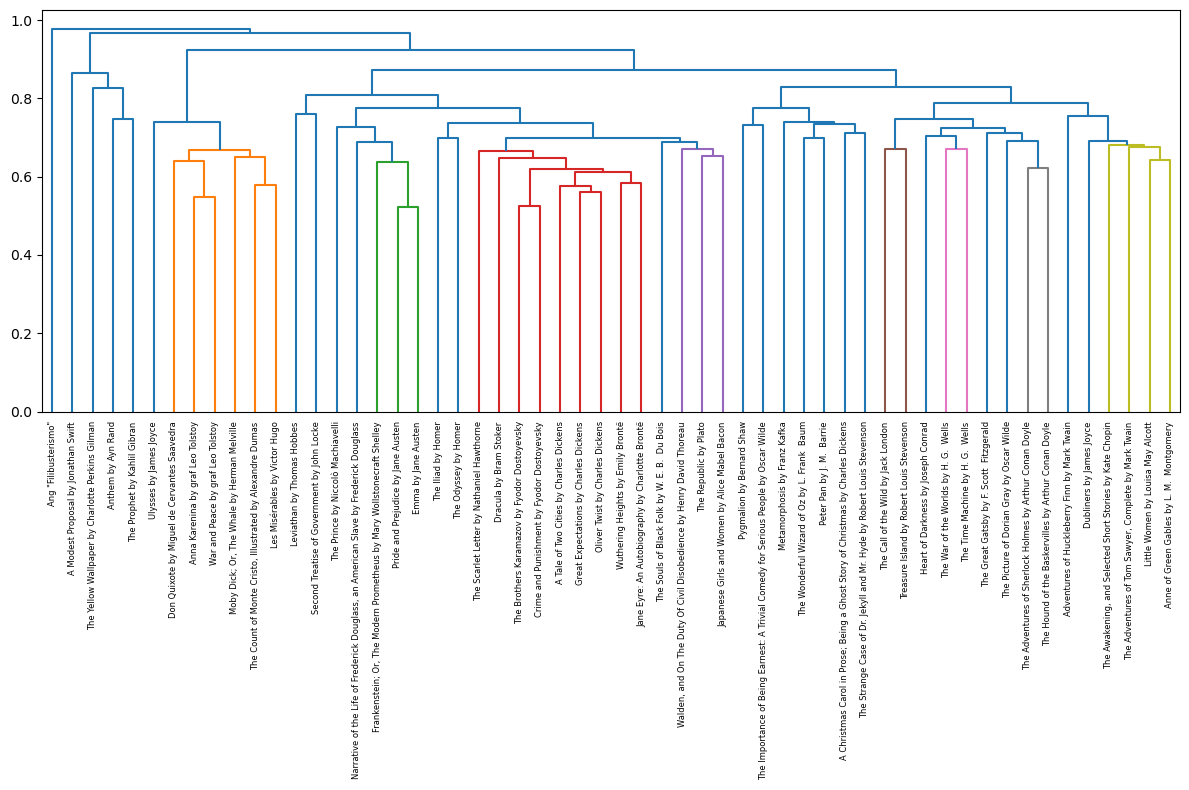

In [47]:
mergings = linkage(squareform(dists), method='complete')

plt.figure(figsize = (12,8))
dendrogram(mergings,
           labels = list(book_tokens.keys()),
           leaf_rotation = 90,
           leaf_font_size = 6);

plt.tight_layout()
plt.savefig('../dendogram_complete_jaccard.png', transparent=False, facecolor='white', dpi = 150);

**Bonus Material** Jaccard Similarity does not account for the frequency that each word is used, only whether or not it is used.

We might be better off using the **cosine similarity** as a way to measure the similarity of two books.

Create a dataframe named `books_df` where each row corresponds to a book and each column corresponds to a word. It should count the number of times the word appears in that book (including zero). Use the book title as the index of this dataframe.

In [48]:
import pandas as pd
from collections import Counter

# Get vocabulary (all unique words across all books)
vocab = set()

for tokens in book_tokens.values():
    vocab.update(tokens)

vocab = sorted(list(vocab))  # consistent column order

# Initialize dataframe (filled with zeros)
books_df = pd.DataFrame(0, index=book_tokens.keys(), columns=vocab)

# Fill with word counts
for title, text in books.items():
    
    # tokenize raw text (NOT set, we need frequencies)
    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())
    counts = Counter(words)
    
    for word, count in counts.items():
        if word in books_df.columns:
            books_df.loc[title, word] = count

books_df

,a,aaaaaah,aaah,aabogado,aabot,aabutan,aagahan,aagam,aagawin,aah,...,zulu,zulus,zum,zurbaran,zurich,zuyderzee,zuz,zweck,zy,zygomatic
Pygmalion by Bernard Shaw,827,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
The War of the Worlds by H. G. Wells,1636,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Leviathan by Thomas Hobbes,3145,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Don Quixote by Miguel de Cervantes Saavedra,7139,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"The Awakening, and Selected Short Stories by Kate Chopin",1467,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"The Count of Monte Cristo, Illustrated by Alexandre Dumas",9410,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
Les Misérables by Victor Hugo,14469,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
The Republic by Plato,3929,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"Walden, and On The Duty Of Civil Disobedience by Henry David Thoreau",3051,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Dubliners by James Joyce,1586,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
